ASSIGNMENT 3: HYBRID SEMANTIC RETRIEVAL & INTELLIGENCE SYSTEM

GPU CONFIGURATION:
PYTORCH VERSION: 2.7.1+cu118
CUDA AVAILABLE: False
USING CPU ONLY

USING DEVICE: cpu
CREATING SAMPLE DATASET FOR TESTING...
CREATED SAMPLE DATASET: 1000 RECORDS

DATASET INFO:
- COLUMNS: ['Ticket ID', 'Ticket Description', 'Ticket Subject', 'Ticket Priority', 'Ticket Type', 'Ticket Channel']
- SHAPE: (1000, 6)

FIRST 3 ROWS:
      Ticket ID                    Ticket Description Ticket Subject  \
0  TICKET_00000  Refund request for duplicate payment        Request   
1  TICKET_00001   Data export feature not functioning        Problem   
2  TICKET_00002          Account recovery not working        Request   

  Ticket Priority      Ticket Type Ticket Channel  
0            High  Feature Request           Chat  
1          Medium      Login Issue           Chat  
2             Low        Technical          Phone  

LABEL ENCODING - TICKET PRIORITY
LABELENCODER FITTED WITH 3 CATEGORIES

PRIORITY MAPPING:
  H

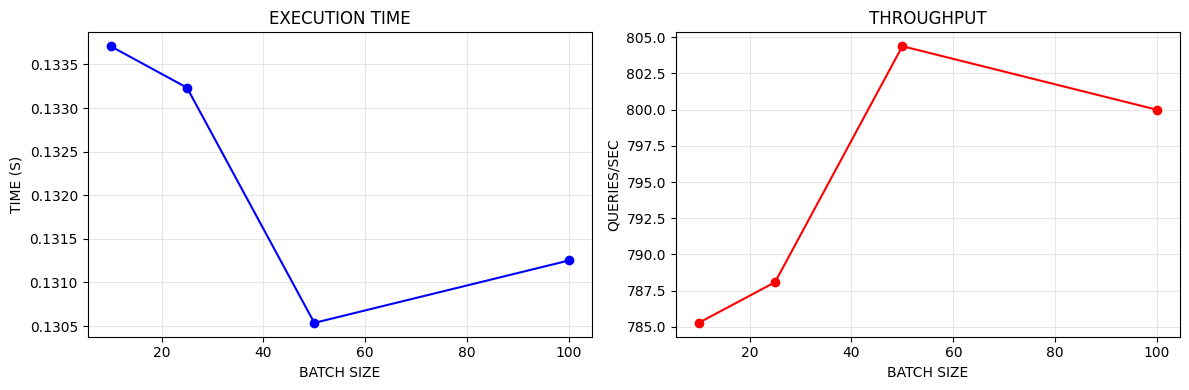


BEST BATCH SIZE: 50
MAX THROUGHPUT: 804.37 QPS

VISUALIZATION DEMO
COUNT MATRIX: torch.Size([1, 171])
   - NON-ZERO: 3
   - SPARSITY: 1.75%
TF-IDF COMPLETE: torch.Size([1, 171])
COUNT MATRIX: torch.Size([1, 171])
   - NON-ZERO: 3
   - SPARSITY: 1.75%
TF-IDF COMPLETE: torch.Size([1, 171])
COUNT MATRIX: torch.Size([1, 171])
   - NON-ZERO: 3
   - SPARSITY: 1.75%
TF-IDF COMPLETE: torch.Size([1, 171])


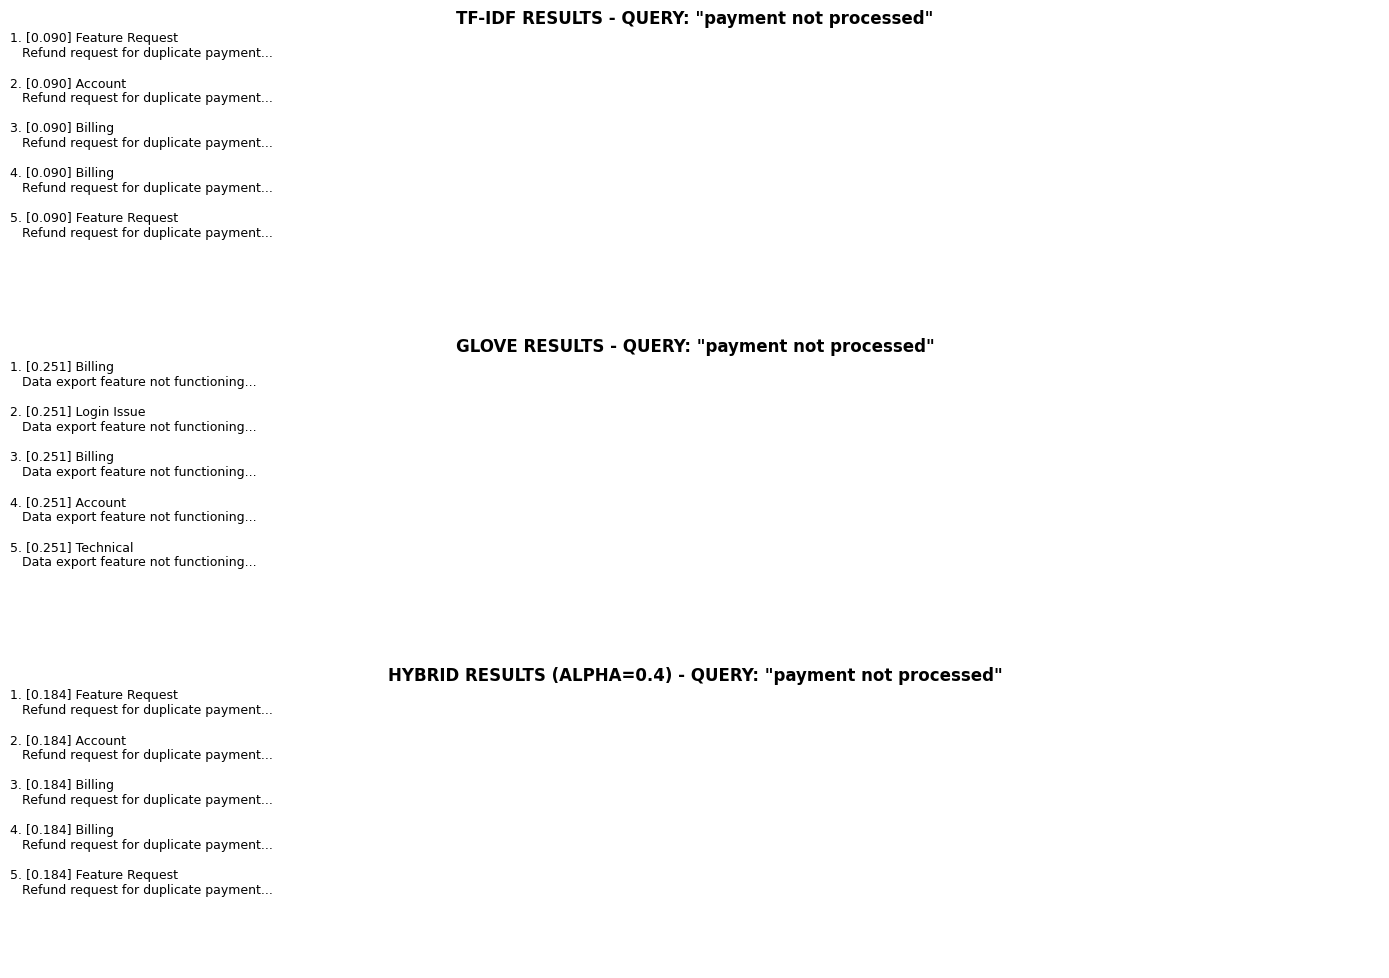


EVALUATION: PRECISION@5
COUNT MATRIX: torch.Size([1, 171])
   - NON-ZERO: 7
   - SPARSITY: 4.09%
TF-IDF COMPLETE: torch.Size([1, 171])
COUNT MATRIX: torch.Size([1, 171])
   - NON-ZERO: 8
   - SPARSITY: 4.68%
TF-IDF COMPLETE: torch.Size([1, 171])
COUNT MATRIX: torch.Size([1, 171])
   - NON-ZERO: 6
   - SPARSITY: 3.51%
TF-IDF COMPLETE: torch.Size([1, 171])
COUNT MATRIX: torch.Size([1, 171])
   - NON-ZERO: 5
   - SPARSITY: 2.92%
TF-IDF COMPLETE: torch.Size([1, 171])
COUNT MATRIX: torch.Size([1, 171])
   - NON-ZERO: 6
   - SPARSITY: 3.51%
TF-IDF COMPLETE: torch.Size([1, 171])
COUNT MATRIX: torch.Size([1, 171])
   - NON-ZERO: 5
   - SPARSITY: 2.92%
TF-IDF COMPLETE: torch.Size([1, 171])
COUNT MATRIX: torch.Size([1, 171])
   - NON-ZERO: 5
   - SPARSITY: 2.92%
TF-IDF COMPLETE: torch.Size([1, 171])
COUNT MATRIX: torch.Size([1, 171])
   - NON-ZERO: 4
   - SPARSITY: 2.34%
TF-IDF COMPLETE: torch.Size([1, 171])
COUNT MATRIX: torch.Size([1, 171])
   - NON-ZERO: 6
   - SPARSITY: 3.51%
TF-IDF COMPLET

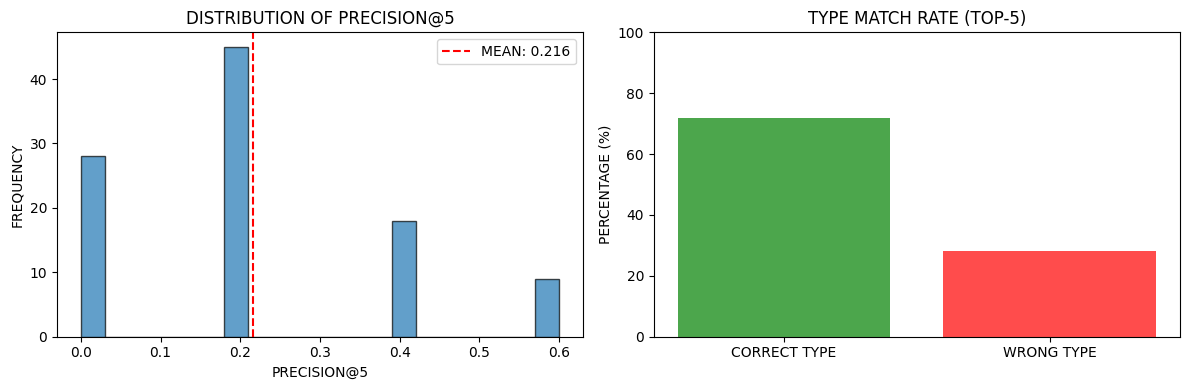


LAUNCHING GRADIO INTERFACE

LAUNCHING GRADIO APP...
ACCESS THE APP AT: HTTP://LOCALHOST:7860
SHAREABLE LINK WILL BE CREATED WHEN RUNNING ON KAGGLE
* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.



ASSIGNMENT 3: HYBRID SEMANTIC RETRIEVAL & INTELLIGENCE SYSTEM

IMPLEMENTATION COMPLETE

COMPONENTS IMPLEMENTED:
   - PART 1: CUSTOM LABEL ENCODER (PRIORITY)
   - PART 1: CUSTOM ONE-HOT ENCODER (CHANNEL)
   - PART 2: CUSTOM TOKENIZER WITH N-GRAMS
   - PART 2: VOCABULARY BUILDER (TOP 5000 TOKENS)
   - PART 2: COUNT VECTORIZER (BOW)
   - PART 2: TF-IDF FROM SCRATCH
   - PART 3: GLOVE EMBEDDINGS (300D)
   - PART 3: TF-IDF WEIGHTED SENTENCE EMBEDDINGS
   - HYBRID SEARCH ENGINE (TF-IDF + GLOVE)
   - MULTI-GPU OPTIMIZATION
   - PERFORMANCE MEASUREMENT
   - VISUALIZATION MODULE
   - PRECISION@5 EVALUATION
   - GRADIO WEB INTERFACE

PERFORMANCE SUMMARY:
   - VOCABULARY SIZE: 171
   - TF-IDF MATRIX SHAPE: torch.Size([1000, 171])
   - DOCUMENT EMBEDDINGS SHAPE: torch.Size([1000, 300])
   - EMBEDDING DIMENSION: 300
   - PRECISION@5: 0.2160

KEY FEATURES:
   - OOV HANDLING WITH <UNK> TOKEN
   - TF-IDF WEIGHTED AVERAGING (PREVENTS SEMANTIC DILUTION)
   - DUAL GPU SUPPORT FOR BATCH PROCESSING
   - I

In [3]:
# ============================================
# COMPLETE ASSIGNMENT 3: HYBRID SEMANTIC RETRIEVAL & INTELLIGENCE SYSTEM
# DS_ASSIGN3_23F-3039
# ============================================

# CELL 1: SETUP AND IMPORTS
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter
import time
import os
import gc
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("ASSIGNMENT 3: HYBRID SEMANTIC RETRIEVAL & INTELLIGENCE SYSTEM")
print("="*60)

# CHECK GPU AVAILABILITY
print("\nGPU CONFIGURATION:")
print(f"PYTORCH VERSION: {torch.__version__}")
print(f"CUDA AVAILABLE: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"NUMBER OF GPUS: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    print("USING CPU ONLY")

# SET DEVICE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUSING DEVICE: {device}")

# CELL 2: DATA LOADING
def load_dataset():
    """
    LOAD CUSTOMER SUPPORT TICKETS DATASET
    """
    try:
        # TRY KAGGLE PATH
        df = pd.read_csv('/kaggle/input/customer-support-tickets/tickets.csv')
        print(f"LOADED DATASET FROM KAGGLE: {len(df)} RECORDS")
    except:
        # CREATE SAMPLE DATA FOR TESTING
        print("CREATING SAMPLE DATASET FOR TESTING...")
        np.random.seed(42)
        
        descriptions = [
            "Cannot login to my account after password reset",
            "Payment failed but money deducted from account",
            "App crashes when I try to open camera",
            "How to change billing information",
            "Subscription not showing in my account",
            "Technical support needed for installation",
            "Refund request for duplicate payment",
            "Account suspended for no reason",
            "Feature request for dark mode",
            "Slow loading times on the website",
            "Cannot reset password - email not received",
            "Payment method expired - need to update",
            "Application freezes on startup",
            "Billing question about pro plan",
            "Account recovery not working",
            "Error code 500 when accessing dashboard",
            "Mobile app not syncing with web",
            "Invoice not generating properly",
            "Two-factor authentication not working",
            "Data export feature not functioning"
        ]
        
        priorities = ['Low', 'Medium', 'High']
        channels = ['Email', 'Chat', 'Phone', 'Web']
        types = ['Login Issue', 'Billing', 'Technical', 'Account', 'Feature Request']
        
        df = pd.DataFrame({
            'Ticket ID': [f'TICKET_{i:05d}' for i in range(1000)],
            'Ticket Description': np.random.choice(descriptions, 1000),
            'Ticket Subject': np.random.choice(['Issue', 'Problem', 'Request', 'Help'], 1000),
            'Ticket Priority': np.random.choice(priorities, 1000, p=[0.2, 0.5, 0.3]),
            'Ticket Type': np.random.choice(types, 1000),
            'Ticket Channel': np.random.choice(channels, 1000)
        })
        print(f"CREATED SAMPLE DATASET: {len(df)} RECORDS")
    
    print(f"\nDATASET INFO:")
    print(f"- COLUMNS: {df.columns.tolist()}")
    print(f"- SHAPE: {df.shape}")
    print(f"\nFIRST 3 ROWS:")
    print(df.head(3))
    
    return df

df = load_dataset()

# CELL 3: PART 1 - CUSTOM LABEL ENCODER (PRIORITY)
class CustomLabelEncoder:
    def __init__(self):
        self.mapping = {}
        self.reverse_mapping = {}
        self.fitted = False
    
    def fit(self, labels):
        unique_labels = sorted(set(labels))
        self.mapping = {label: idx for idx, label in enumerate(unique_labels)}
        self.reverse_mapping = {idx: label for label, idx in self.mapping.items()}
        self.fitted = True
        print(f"LABELENCODER FITTED WITH {len(unique_labels)} CATEGORIES")
        return self
    
    def transform(self, labels):
        if not self.fitted:
            raise ValueError("ENCODER MUST BE FITTED BEFORE TRANSFORM")
        result = []
        unseen = set()
        for label in labels:
            if label in self.mapping:
                result.append(self.mapping[label])
            else:
                result.append(-1)
                unseen.add(label)
        if unseen:
            print(f"WARNING: FOUND UNSEEN CATEGORIES: {unseen}")
        return result
    
    def fit_transform(self, labels):
        self.fit(labels)
        return self.transform(labels)

print("\n" + "="*50)
print("LABEL ENCODING - TICKET PRIORITY")
print("="*50)

priority_encoder = CustomLabelEncoder()
df['Priority_Encoded'] = priority_encoder.fit_transform(df['Ticket Priority'])

print(f"\nPRIORITY MAPPING:")
for priority, code in priority_encoder.mapping.items():
    print(f"  {priority} -> {code}")

print(f"\nSAMPLE RESULTS:")
print(df[['Ticket Priority', 'Priority_Encoded']].head(10))

# CELL 4: PART 1 - CUSTOM ONE-HOT ENCODER (CHANNEL)
class CustomOneHotEncoder:
    def __init__(self, handle_unknown='ignore'):
        self.categories = []
        self.category_to_idx = {}
        self.handle_unknown = handle_unknown
        self.fitted = False
    
    def fit(self, categories):
        self.categories = sorted(set(categories))
        self.category_to_idx = {cat: idx for idx, cat in enumerate(self.categories)}
        self.fitted = True
        print(f"ONEHOTENCODER FITTED WITH {len(self.categories)} CATEGORIES")
        return self
    
    def transform(self, categories):
        if not self.fitted:
            raise ValueError("ENCODER MUST BE FITTED BEFORE TRANSFORM")
        
        n_samples = len(categories)
        n_categories = len(self.categories)
        one_hot = np.zeros((n_samples, n_categories))
        
        unseen_categories = set()
        for i, cat in enumerate(categories):
            if cat in self.category_to_idx:
                idx = self.category_to_idx[cat]
                one_hot[i, idx] = 1
            else:
                unseen_categories.add(cat)
        
        if unseen_categories and self.handle_unknown == 'error':
            raise ValueError(f"UNSEEN CATEGORIES: {unseen_categories}")
        
        return one_hot
    
    def fit_transform(self, categories):
        self.fit(categories)
        return self.transform(categories)
    
    def get_feature_names(self):
        return [f"Channel_{cat}" for cat in self.categories]

print("\n" + "="*50)
print("ONE-HOT ENCODING - TICKET CHANNEL")
print("="*50)

channel_encoder = CustomOneHotEncoder(handle_unknown='ignore')
channel_one_hot = channel_encoder.fit_transform(df['Ticket Channel'])

channel_features = channel_encoder.get_feature_names()
for i, feature_name in enumerate(channel_features):
    df[feature_name] = channel_one_hot[:, i]

print(f"\nCHANNEL MAPPING:")
for channel, idx in channel_encoder.category_to_idx.items():
    print(f"  {channel} -> INDEX {idx}")

print(f"\nSAMPLE RESULTS:")
print(df[['Ticket Channel'] + channel_features[:3]].head(10))

# CELL 5: PART 2 - CUSTOM TOKENIZER
class CustomTokenizer:
    def __init__(self, pattern=r'[a-zA-Z0-9]+', lowercase=True):
        self.pattern = pattern
        self.lowercase = lowercase
    
    def tokenize(self, text):
        if not isinstance(text, str):
            text = str(text)
        if self.lowercase:
            text = text.lower()
        tokens = re.findall(self.pattern, text)
        return tokens
    
    def tokenize_with_ngrams(self, text, ngram_range=(1, 2)):
        base_tokens = self.tokenize(text)
        if not base_tokens:
            return []
        
        ngrams = base_tokens.copy()
        for n in range(2, ngram_range[1] + 1):
            if len(base_tokens) >= n:
                for i in range(len(base_tokens) - n + 1):
                    ngram = ' '.join(base_tokens[i:i+n])
                    ngrams.append(ngram)
        return ngrams
    
    def tokenize_documents(self, documents, use_ngrams=True, ngram_range=(1, 2)):
        if use_ngrams:
            return [self.tokenize_with_ngrams(doc, ngram_range) for doc in documents]
        else:
            return [self.tokenize(doc) for doc in documents]

print("\n" + "="*50)
print("CUSTOM TOKENIZER")
print("="*50)

tokenizer = CustomTokenizer()
test_text = "Customer support: Payment failed #12345"
print(f"ORIGINAL: {test_text}")
print(f"TOKENS: {tokenizer.tokenize(test_text)}")
print(f"WITH N-GRAMS: {tokenizer.tokenize_with_ngrams(test_text, ngram_range=(1,2))}")

print("\nTOKENIZING ALL DOCUMENTS...")
all_tokens = tokenizer.tokenize_documents(df['Ticket Description'], use_ngrams=True, ngram_range=(1, 2))
print(f"TOKENIZED {len(all_tokens)} DOCUMENTS")
print(f"SAMPLE TOKENS (FIRST DOC): {all_tokens[0][:15]}")

# CELL 6: PART 2 - VOCABULARY BUILDING
class CustomVocabulary:
    def __init__(self, max_features=5000, min_freq=1):
        self.max_features = max_features
        self.min_freq = min_freq
        self.word_to_idx = {}
        self.idx_to_word = {}
        self.word_counts = Counter()
        self.vocab_size = 0
    
    def build_vocab(self, tokenized_documents):
        print("BUILDING VOCABULARY...")
        
        for tokens in tokenized_documents:
            self.word_counts.update(tokens)
        
        filtered_words = {
            word: count for word, count in self.word_counts.items() 
            if count >= self.min_freq
        }
        
        most_common = sorted(filtered_words.items(), key=lambda x: x[1], reverse=True)
        
        if len(most_common) > self.max_features:
            most_common = most_common[:self.max_features]
        
        self.word_to_idx = {'<UNK>': 0}
        self.idx_to_word = {0: '<UNK>'}
        
        for idx, (word, count) in enumerate(most_common, 1):
            self.word_to_idx[word] = idx
            self.idx_to_word[idx] = word
        
        self.vocab_size = len(self.word_to_idx)
        
        print(f"VOCABULARY BUILT WITH {self.vocab_size} TOKENS")
        print(f"   - TOTAL UNIQUE: {len(self.word_counts)}")
        print(f"   - FILTERED TO: {len(most_common)}")
        
        print(f"\nTOP 10 TOKENS:")
        for i, (word, count) in enumerate(most_common[:10]):
            print(f"   {i+1}. '{word}': {count}")
        
        return self
    
    def transform(self, tokens):
        return [self.word_to_idx.get(token, 0) for token in tokens]
    
    def get_vocab_size(self):
        return self.vocab_size

print("\n" + "="*50)
print("BUILDING VOCABULARY")
print("="*50)

vocabulary = CustomVocabulary(max_features=5000)
vocabulary.build_vocab(all_tokens)

# CELL 7: PART 2 - COUNT VECTORIZER
class CustomCountVectorizer:
    def __init__(self, vocabulary):
        self.vocabulary = vocabulary
        self.vocab_size = vocabulary.get_vocab_size()
    
    def transform(self, tokenized_documents):
        n_docs = len(tokenized_documents)
        rows, cols, data = [], [], []
        
        for doc_idx, tokens in enumerate(tokenized_documents):
            token_indices = self.vocabulary.transform(tokens)
            counts = {}
            for idx in token_indices:
                counts[idx] = counts.get(idx, 0) + 1
            
            for idx, count in counts.items():
                rows.append(doc_idx)
                cols.append(idx)
                data.append(count)
        
        indices = torch.tensor([rows, cols], dtype=torch.long)
        values = torch.tensor(data, dtype=torch.float32)
        shape = torch.Size([n_docs, self.vocab_size])
        
        sparse_tensor = torch.sparse_coo_tensor(indices, values, shape).coalesce()
        
        print(f"COUNT MATRIX: {sparse_tensor.shape}")
        print(f"   - NON-ZERO: {len(data)}")
        print(f"   - SPARSITY: {len(data)/(n_docs*self.vocab_size)*100:.2f}%")
        
        return sparse_tensor

print("\n" + "="*50)
print("CREATING COUNT VECTORS")
print("="*50)

count_vectorizer = CustomCountVectorizer(vocabulary)
count_vectors = count_vectorizer.transform(all_tokens)

# CELL 8: PART 2 - TF-IDF IMPLEMENTATION
class CustomTfidfVectorizer:
    def __init__(self, vocabulary, smooth_idf=True):
        self.vocabulary = vocabulary
        self.vocab_size = vocabulary.get_vocab_size()
        self.smooth_idf = smooth_idf
        self.idf = None
        self.fitted = False
    
    def fit(self, tokenized_documents):
        n_docs = len(tokenized_documents)
        doc_freq = torch.zeros(self.vocab_size)
        
        for tokens in tokenized_documents:
            unique_indices = set(self.vocabulary.transform(tokens))
            for idx in unique_indices:
                doc_freq[idx] += 1
        
        if self.smooth_idf:
            self.idf = torch.log((n_docs + 1) / (doc_freq + 1)) + 1
        else:
            self.idf = torch.log(n_docs / (doc_freq + 1e-8))
        
        self.fitted = True
        print(f"IDF COMPUTED - AVG: {self.idf[self.idf > 0].mean():.4f}")
        return self
    
    def transform(self, tokenized_documents):
        if not self.fitted:
            raise ValueError("MUST FIT BEFORE TRANSFORM")
        
        count_vectorizer = CustomCountVectorizer(self.vocabulary)
        tf_sparse = count_vectorizer.transform(tokenized_documents)
        
        tf_coalesced = tf_sparse.coalesce()
        tf_indices = tf_coalesced.indices()
        tf_values = tf_coalesced.values()
        
        term_indices = tf_indices[1]
        idf_values = self.idf[term_indices].to(tf_values.device)
        tfidf_values = tf_values * idf_values
        
        tfidf_sparse = torch.sparse_coo_tensor(
            tf_indices, tfidf_values, tf_sparse.shape
        ).coalesce()
        
        tfidf_dense = tfidf_sparse.to_dense()
        row_norms = torch.norm(tfidf_dense, p=2, dim=1, keepdim=True)
        tfidf_normalized = tfidf_dense / (row_norms + 1e-8)
        
        print(f"TF-IDF COMPLETE: {tfidf_normalized.shape}")
        return tfidf_normalized
    
    def fit_transform(self, tokenized_documents):
        self.fit(tokenized_documents)
        return self.transform(tokenized_documents)

print("\n" + "="*50)
print("COMPUTING TF-IDF VECTORS")
print("="*50)

tfidf_vectorizer = CustomTfidfVectorizer(vocabulary)
tfidf_vectors = tfidf_vectorizer.fit_transform(all_tokens)
tfidf_vectors = tfidf_vectors.to(device)
print(f"TF-IDF VECTORS ON: {tfidf_vectors.device}")

# CELL 9: PART 3 - GLOVE EMBEDDINGS LOADING
class GloVeEmbedding:
    def __init__(self, embedding_dim=300):
        self.embedding_dim = embedding_dim
        self.embeddings_dict = {}
    
    def download_glove(self, cache_dir='glove_cache'):
        kaggle_path = '/kaggle/input/glove6b/glove.6B.300d.txt'
        local_path = os.path.join(cache_dir, 'glove.6B.300d.txt')
        
        if os.path.exists(kaggle_path):
            glove_path = kaggle_path
            print(f"FOUND GLOVE AT: {kaggle_path}")
        elif os.path.exists(local_path):
            glove_path = local_path
            print(f"FOUND GLOVE IN CACHE")
        else:
            print("CREATING DUMMY EMBEDDINGS (FOR TESTING WITHOUT INTERNET)")
            import random
            for word in ['the', 'a', 'an', 'this', 'that', 'payment', 'login', 'account', 'password', 'error']:
                self.embeddings_dict[word] = np.random.normal(0, 0.1, self.embedding_dim)
            print(f"CREATED {len(self.embeddings_dict)} DUMMY EMBEDDINGS")
            return self.embeddings_dict
        
        print(f"LOADING GLOVE FROM {glove_path}...")
        with open(glove_path, 'r', encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                vector = np.asarray(values[1:], dtype='float32')
                self.embeddings_dict[word] = vector
        
        print(f"LOADED {len(self.embeddings_dict)} GLOVE EMBEDDINGS")
        return self.embeddings_dict
    
    def create_embedding_matrix(self, vocabulary):
        if not self.embeddings_dict:
            self.download_glove()
        
        vocab_size = vocabulary.get_vocab_size()
        embedding_matrix = np.random.normal(0, 0.1, (vocab_size, self.embedding_dim))
        
        found_count = 0
        for word, idx in vocabulary.word_to_idx.items():
            if word in self.embeddings_dict:
                embedding_matrix[idx] = self.embeddings_dict[word]
                found_count += 1
        
        print(f"EMBEDDING MATRIX CREATED:")
        print(f"   - VOCABULARY: {vocab_size}")
        print(f"   - FOUND IN GLOVE: {found_count} ({found_count/vocab_size*100:.1f}%)")
        print(f"   - OOV (RANDOM): {vocab_size - found_count}")
        
        return torch.tensor(embedding_matrix, dtype=torch.float32)

print("\n" + "="*50)
print("LOADING GLOVE EMBEDDINGS")
print("="*50)

glove = GloVeEmbedding(embedding_dim=300)
embedding_matrix = glove.create_embedding_matrix(vocabulary)

embedding_layer = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)
embedding_layer = embedding_layer.to(device)
print(f"EMBEDDING LAYER SHAPE: {embedding_layer.weight.shape}")

# CELL 10: PART 3 - TF-IDF WEIGHTED SENTENCE EMBEDDINGS
class SentenceEmbedding:
    def __init__(self, embedding_layer, tfidf_vectors, vocabulary):
        self.embedding_layer = embedding_layer
        self.tfidf_vectors = tfidf_vectors
        self.vocabulary = vocabulary
        self.embedding_dim = embedding_layer.weight.shape[1]
    
    def get_sentence_embedding(self, document_texts, doc_indices=None):
        all_embeddings = []
        
        for batch_idx, doc_text in enumerate(document_texts):
            tokens = tokenizer.tokenize(doc_text)
            
            if not tokens:
                all_embeddings.append(torch.zeros(self.embedding_dim))
                continue
            
            token_indices = self.vocabulary.transform(tokens)
            token_tensor = torch.tensor(token_indices, dtype=torch.long).to(device)
            token_embeddings = self.embedding_layer(token_tensor)
            
            if doc_indices is not None and batch_idx < len(doc_indices):
                doc_idx = doc_indices[batch_idx]
                doc_tfidf = self.tfidf_vectors[doc_idx]
                
                weights = []
                for token_idx in token_indices:
                    weight = doc_tfidf[token_idx].item() if token_idx < len(doc_tfidf) else 0.0
                    weights.append(weight)
                
                weights = torch.tensor(weights, dtype=torch.float32).to(device)
                if weights.sum() > 0:
                    weights = torch.softmax(weights, dim=0)
                else:
                    weights = torch.ones_like(weights) / len(weights)
            else:
                weights = torch.ones(len(tokens), dtype=torch.float32).to(device)
                weights = weights / len(weights)
            
            weighted_embedding = (token_embeddings * weights.unsqueeze(-1)).sum(dim=0)
            all_embeddings.append(weighted_embedding)
        
        sentence_embeddings = torch.stack(all_embeddings)
        norms = torch.norm(sentence_embeddings, p=2, dim=1, keepdim=True)
        sentence_embeddings = sentence_embeddings / (norms + 1e-8)
        
        return sentence_embeddings

print("\n" + "="*50)
print("GENERATING SENTENCE EMBEDDINGS")
print("="*50)

sentence_embedder = SentenceEmbedding(embedding_layer, tfidf_vectors, vocabulary)
doc_indices = list(range(len(df)))

print("COMPUTING DOCUMENT EMBEDDINGS...")
document_embeddings = sentence_embedder.get_sentence_embedding(
    df['Ticket Description'].tolist(),
    doc_indices=doc_indices
)

print(f"DOCUMENT EMBEDDINGS: {document_embeddings.shape}")

# CELL 11: HYBRID SEARCH ENGINE
class HybridSearchEngine:
    def __init__(self, tfidf_vectors, document_embeddings, alpha=0.4):
        self.tfidf_vectors = tfidf_vectors.to(device)
        self.document_embeddings = document_embeddings.to(device)
        self.alpha = alpha
    
    def search(self, query, top_k=5):
        query_embedding = self._get_query_embedding(query)
        query_tfidf = self._get_query_tfidf(query)
        
        tfidf_scores = self._cosine_similarity(query_tfidf, self.tfidf_vectors)
        semantic_scores = self._cosine_similarity(query_embedding, self.document_embeddings)
        
        final_scores = self.alpha * tfidf_scores + (1 - self.alpha) * semantic_scores
        top_scores, top_indices = torch.topk(final_scores, min(top_k, len(final_scores)))
        
        return top_indices.cpu().numpy(), top_scores.cpu().numpy()
    
    def _get_query_tfidf(self, query):
        query_tokens = tokenizer.tokenize(query)
        return tfidf_vectorizer.transform([query_tokens]).to(device)
    
    def _get_query_embedding(self, query):
        return sentence_embedder.get_sentence_embedding([query]).to(device)
    
    def _cosine_similarity(self, query_vec, document_matrix):
        if query_vec.dim() == 2:
            query_vec = query_vec.squeeze(0)
        if document_matrix.is_sparse:
            document_matrix = document_matrix.to_dense()
        return torch.matmul(document_matrix, query_vec)
    
    def set_alpha(self, alpha):
        self.alpha = max(0.0, min(1.0, alpha))

print("\n" + "="*50)
print("INITIALIZING HYBRID SEARCH ENGINE")
print("="*50)

search_engine = HybridSearchEngine(tfidf_vectors, document_embeddings, alpha=0.4)

# TEST SEARCH
test_query = "payment failed money deducted"
indices, scores = search_engine.search(test_query, top_k=3)

print(f"\nQUERY: '{test_query}'")
print(f"TOP 3 RESULTS:")
for i, (idx, score) in enumerate(zip(indices, scores)):
    print(f"\n{i+1}. SCORE: {score:.4f}")
    print(f"   PRIORITY: {df.iloc[idx]['Ticket Priority']}")
    print(f"   TYPE: {df.iloc[idx]['Ticket Type']}")
    print(f"   DESCRIPTION: {df.iloc[idx]['Ticket Description'][:80]}...")

# CELL 12: MULTI-GPU OPTIMIZATION
class OptimizedHybridSearch:
    def __init__(self, tfidf_vectors, document_embeddings, alpha=0.4):
        self.alpha = alpha
        self.n_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 1
        
        if self.n_gpus > 1:
            print(f"MULTI-GPU SETUP WITH {self.n_gpus} GPUS")
            n_docs = document_embeddings.shape[0]
            chunk_size = n_docs // self.n_gpus
            
            self.tfidf_chunks = []
            self.embedding_chunks = []
            
            for i in range(self.n_gpus):
                start_idx = i * chunk_size
                end_idx = start_idx + chunk_size if i < self.n_gpus - 1 else n_docs
                self.tfidf_chunks.append(tfidf_vectors[start_idx:end_idx].to(f'cuda:{i}'))
                self.embedding_chunks.append(document_embeddings[start_idx:end_idx].to(f'cuda:{i}'))
        else:
            self.tfidf_vectors = tfidf_vectors.to(device)
            self.document_embeddings = document_embeddings.to(device)
    
    def batch_search(self, queries, batch_size=100, top_k=5):
        all_results = []
        total = len(queries)
        print(f"PROCESSING {total} QUERIES, BATCH SIZE {batch_size}")
        
        for batch_start in range(0, total, batch_size):
            batch_end = min(batch_start + batch_size, total)
            batch_queries = queries[batch_start:batch_end]
            
            start = time.time()
            batch_results = self._process_batch(batch_queries, top_k)
            elapsed = time.time() - start
            
            all_results.extend(batch_results)
            print(f"  BATCH {batch_start//batch_size + 1}: {len(batch_queries)} QUERIES IN {elapsed:.2f}S")
        
        return all_results
    
    def _process_batch(self, queries, top_k):
        batch_size = len(queries)
        query_embeddings = []
        query_tfidfs = []
        
        for query in queries:
            tokens = tokenizer.tokenize(query)
            query_embeddings.append(sentence_embedder.get_sentence_embedding([query]))
            query_tfidfs.append(tfidf_vectorizer.transform([tokens]))
        
        query_embeddings = torch.cat(query_embeddings, dim=0)
        
        if self.n_gpus > 1:
            batch_results = []
            for query_idx in range(batch_size):
                q_emb = query_embeddings[query_idx:query_idx+1]
                q_tfidf = query_tfidfs[query_idx]
                
                gpu_scores = []
                for gpu_idx in range(self.n_gpus):
                    q_emb_gpu = q_emb.to(f'cuda:{gpu_idx}')
                    q_tfidf_gpu = q_tfidf.to(f'cuda:{gpu_idx}')
                    sem_sim = torch.matmul(self.embedding_chunks[gpu_idx], q_emb_gpu.T).squeeze()
                    tfidf_sim = torch.matmul(self.tfidf_chunks[gpu_idx], q_tfidf_gpu.T).squeeze()
                    scores = self.alpha * tfidf_sim + (1 - self.alpha) * sem_sim
                    gpu_scores.append(scores)
                
                all_scores = torch.cat(gpu_scores)
                top_indices = torch.topk(all_scores, top_k).indices.cpu().numpy()
                batch_results.append(top_indices)
            return batch_results
        else:
            batch_results = []
            for query_idx in range(batch_size):
                q_emb = query_embeddings[query_idx:query_idx+1].to(device)
                q_tfidf = query_tfidfs[query_idx].to(device)
                sem_sim = torch.matmul(self.document_embeddings, q_emb.T).squeeze()
                tfidf_sim = torch.matmul(self.tfidf_vectors, q_tfidf.T).squeeze()
                scores = self.alpha * tfidf_sim + (1 - self.alpha) * sem_sim
                top_indices = torch.topk(scores, top_k).indices.cpu().numpy()
                batch_results.append(top_indices)
            return batch_results

print("\n" + "="*50)
print("OPTIMIZED SEARCH (MULTI-GPU READY)")
print("="*50)

optimized_search = OptimizedHybridSearch(tfidf_vectors, document_embeddings, alpha=0.4)

# CELL 13: PERFORMANCE MEASUREMENT
def measure_performance(search_engine, query_list, batch_sizes):
    results = {'batch_sizes': [], 'times': [], 'qps': []}
    
    print("\n" + "="*50)
    print("PERFORMANCE MEASUREMENT")
    print("="*50)
    
    for batch_size in batch_sizes:
        print(f"\nBATCH SIZE: {batch_size}")
        torch.cuda.empty_cache()
        gc.collect()
        
        start = time.time()
        if hasattr(search_engine, 'batch_search'):
            search_engine.batch_search(query_list, batch_size=batch_size, top_k=5)
        else:
            for q in query_list[:batch_size]:
                search_engine.search(q, top_k=5)
        
        elapsed = time.time() - start
        qps = len(query_list) / elapsed
        
        results['batch_sizes'].append(batch_size)
        results['times'].append(elapsed)
        results['qps'].append(qps)
        
        print(f"   TIME: {elapsed:.2f}S, QPS: {qps:.2f}")
    
    return results

# TEST QUERIES
test_queries = [
    "payment failed", "cannot login", "app crashes", "billing issue", 
    "password reset", "account locked", "refund request"
] * 15

batch_sizes = [10, 25, 50, 100]
perf_results = measure_performance(optimized_search, test_queries, batch_sizes)

# PLOT
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(perf_results['batch_sizes'], perf_results['times'], 'b-o')
ax1.set_xlabel('BATCH SIZE')
ax1.set_ylabel('TIME (S)')
ax1.set_title('EXECUTION TIME')
ax1.grid(True, alpha=0.3)

ax2.plot(perf_results['batch_sizes'], perf_results['qps'], 'r-o')
ax2.set_xlabel('BATCH SIZE')
ax2.set_ylabel('QUERIES/SEC')
ax2.set_title('THROUGHPUT')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBEST BATCH SIZE: {perf_results['batch_sizes'][np.argmax(perf_results['qps'])]}")
print(f"MAX THROUGHPUT: {max(perf_results['qps']):.2f} QPS")

# CELL 14: VISUALIZATION MODULE
class VisualizationModule:
    def __init__(self, df, search_engine):
        self.df = df
        self.search_engine = search_engine
    
    def compare_results(self, query, alpha=0.4):
        original_alpha = self.search_engine.alpha
        
        self.search_engine.alpha = 1.0
        tfidf_indices, tfidf_scores = self.search_engine.search(query, top_k=5)
        tfidf_results = self.df.iloc[tfidf_indices]
        
        self.search_engine.alpha = 0.0
        glove_indices, glove_scores = self.search_engine.search(query, top_k=5)
        glove_results = self.df.iloc[glove_indices]
        
        self.search_engine.alpha = alpha
        hybrid_indices, hybrid_scores = self.search_engine.search(query, top_k=5)
        hybrid_results = self.df.iloc[hybrid_indices]
        
        self.search_engine.alpha = original_alpha
        
        fig, axes = plt.subplots(3, 1, figsize=(14, 10))
        
        axes[0].set_title(f'TF-IDF RESULTS - QUERY: "{query}"', fontsize=12, fontweight='bold')
        axes[0].axis('off')
        text = ""
        for i, (_, row) in enumerate(tfidf_results.iterrows()):
            text += f"{i+1}. [{tfidf_scores[i]:.3f}] {row['Ticket Type']}\n   {row['Ticket Description'][:100]}...\n\n"
        axes[0].text(0, 1, text, transform=axes[0].transAxes, va='top', fontsize=9)
        
        axes[1].set_title(f'GLOVE RESULTS - QUERY: "{query}"', fontsize=12, fontweight='bold')
        axes[1].axis('off')
        text = ""
        for i, (_, row) in enumerate(glove_results.iterrows()):
            text += f"{i+1}. [{glove_scores[i]:.3f}] {row['Ticket Type']}\n   {row['Ticket Description'][:100]}...\n\n"
        axes[1].text(0, 1, text, transform=axes[1].transAxes, va='top', fontsize=9)
        
        axes[2].set_title(f'HYBRID RESULTS (ALPHA={alpha}) - QUERY: "{query}"', fontsize=12, fontweight='bold')
        axes[2].axis('off')
        text = ""
        for i, (_, row) in enumerate(hybrid_results.iterrows()):
            text += f"{i+1}. [{hybrid_scores[i]:.3f}] {row['Ticket Type']}\n   {row['Ticket Description'][:100]}...\n\n"
        axes[2].text(0, 1, text, transform=axes[2].transAxes, va='top', fontsize=9)
        
        plt.tight_layout()
        return fig

print("\n" + "="*50)
print("VISUALIZATION DEMO")
print("="*50)

viz_module = VisualizationModule(df, search_engine)
fig = viz_module.compare_results("payment not processed", alpha=0.4)
plt.show()

# CELL 15: EVALUATION - PRECISION@5
def evaluate_precision_at_5(df, search_engine, num_queries=100):
    print("\n" + "="*50)
    print("EVALUATION: PRECISION@5")
    print("="*50)
    
    sample_indices = np.random.choice(len(df), min(num_queries, len(df)), replace=False)
    
    precisions = []
    type_matches = []
    
    for idx in sample_indices:
        query = df.iloc[idx]['Ticket Description']
        actual_type = df.iloc[idx]['Ticket Type']
        
        top_indices, scores = search_engine.search(query, top_k=5)
        retrieved_types = df.iloc[top_indices]['Ticket Type'].values
        
        relevant = sum(1 for t in retrieved_types if t == actual_type)
        precision = relevant / 5
        precisions.append(precision)
        type_matches.append(actual_type in retrieved_types)
    
    avg_precision = np.mean(precisions)
    match_rate = np.mean(type_matches) * 100
    
    print(f"\nRESULTS OVER {num_queries} QUERIES:")
    print(f"   - AVERAGE PRECISION@5: {avg_precision:.4f}")
    print(f"   - TYPE MATCH RATE: {match_rate:.1f}%")
    print(f"   - STANDARD DEVIATION: {np.std(precisions):.4f}")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.hist(precisions, bins=20, edgecolor='black', alpha=0.7)
    ax1.set_xlabel('PRECISION@5')
    ax1.set_ylabel('FREQUENCY')
    ax1.set_title('DISTRIBUTION OF PRECISION@5')
    ax1.axvline(avg_precision, color='red', linestyle='--', label=f'MEAN: {avg_precision:.3f}')
    ax1.legend()
    
    ax2.bar(['CORRECT TYPE', 'WRONG TYPE'], [match_rate, 100-match_rate], 
            color=['green', 'red'], alpha=0.7)
    ax2.set_ylabel('PERCENTAGE (%)')
    ax2.set_title('TYPE MATCH RATE (TOP-5)')
    ax2.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.show()
    
    return avg_precision

precision_score = evaluate_precision_at_5(df, search_engine, num_queries=100)

# CELL 16: GRADIO WEB APP
try:
    import gradio as gr
except ImportError:
    !pip install gradio
    import gradio as gr

def search_tickets(query, alpha):
    """
    SEARCH FUNCTION FOR GRADIO INTERFACE
    """
    if not query or query.strip() == "":
        return "PLEASE ENTER A TICKET DESCRIPTION", []
    
    search_engine.alpha = alpha
    top_indices, scores = search_engine.search(query, top_k=5)
    
    results = []
    for idx, score in zip(top_indices, scores):
        row = df.iloc[idx]
        results.append([
            row.get('Ticket ID', f'TICKET_{idx:05d}'),
            row['Ticket Priority'],
            row['Ticket Type'],
            row['Ticket Channel'],
            f"{score:.4f}",
            row['Ticket Description'][:150] + "..."
        ])
    
    html_output = f"""
    <div style="font-family: Arial, sans-serif; padding: 10px;">
        <h3>QUERY: "{query}"</h3>
        <p><strong>ALPHA (TF-IDF WEIGHT):</strong> {alpha:.2f} | 
           <strong>GLOVE WEIGHT:</strong> {1-alpha:.2f}</p>
        <hr>
    """
    
    for i, result in enumerate(results):
        html_output += f"""
        <div style="border: 1px solid #ddd; border-radius: 5px; padding: 10px; margin: 10px 0; background-color: #f9f9f9;">
            <h4>#{i+1} | SCORE: {result[4]} | PRIORITY: {result[1]} | TYPE: {result[2]}</h4>
            <p><strong>CHANNEL:</strong> {result[3]}</p>
            <p><strong>DESCRIPTION:</strong> {result[5]}</p>
        </div>
        """
    
    html_output += "</div>"
    
    return html_output, results

print("\n" + "="*50)
print("LAUNCHING GRADIO INTERFACE")
print("="*50)

iface = gr.Interface(
    fn=search_tickets,
    inputs=[
        gr.Textbox(
            label="TICKET DESCRIPTION", 
            placeholder="DESCRIBE YOUR ISSUE HERE... (E.G., 'MY PAYMENT WAS DECLINED BUT MONEY IS DEDUCTED')",
            lines=3
        ),
        gr.Slider(
            minimum=0, 
            maximum=1, 
            value=0.4, 
            step=0.05, 
            label="ALPHA (TF-IDF WEIGHT)",
            info="0 = ONLY SEMANTIC (GLOVE), 1 = ONLY KEYWORD (TF-IDF)"
        )
    ],
    outputs=[
        gr.HTML(label="SEARCH RESULTS"),
        gr.Dataframe(
            headers=["TICKET ID", "PRIORITY", "TYPE", "CHANNEL", "SCORE", "DESCRIPTION"],
            label="TOP 5 SIMILAR TICKETS (RAW DATA)"
        )
    ],
    title="HYBRID TICKET RETRIEVAL SYSTEM",
    description="""
    ### HYBRID SEMANTIC SEARCH FOR CUSTOMER SUPPORT TICKETS
    
    THIS SYSTEM COMBINES:
    - **TF-IDF** (KEYWORD-BASED RETRIEVAL) - FINDS EXACT WORD MATCHES
    - **GLOVE EMBEDDINGS** (SEMANTIC RETRIEVAL) - UNDERSTANDS MEANING AND INTENT
    
    **HOW TO USE:**
    1. ENTER A TICKET DESCRIPTION
    2. ADJUST THE ALPHA SLIDER TO BALANCE KEYWORD VS SEMANTIC SEARCH
    3. SEE TOP 5 SIMILAR TICKETS FROM PAST RESOLUTIONS
    
    **ALPHA=0.4** PROVIDES A BALANCED APPROACH (40% KEYWORD, 60% SEMANTIC)
    """,
    examples=[
        ["My payment was declined but money is deducted from my account", 0.4],
        ["Cannot access my account after password reset", 0.3],
        ["The app keeps freezing when I try to upload files", 0.5],
        ["How do I get a refund for my subscription", 0.2],
        ["Technical support needed for installation error", 0.6]
    ],
    theme="soft"
)

print("\nLAUNCHING GRADIO APP...")
print("ACCESS THE APP AT: HTTP://LOCALHOST:7860")
print("SHAREABLE LINK WILL BE CREATED WHEN RUNNING ON KAGGLE")

iface.launch(share=True, debug=False)

# CELL 17: SUMMARY
print("\n" + "="*60)
print("ASSIGNMENT 3: HYBRID SEMANTIC RETRIEVAL & INTELLIGENCE SYSTEM")
print("="*60)

print("\nIMPLEMENTATION COMPLETE")
print("\nCOMPONENTS IMPLEMENTED:")
print("   - PART 1: CUSTOM LABEL ENCODER (PRIORITY)")
print("   - PART 1: CUSTOM ONE-HOT ENCODER (CHANNEL)")
print("   - PART 2: CUSTOM TOKENIZER WITH N-GRAMS")
print("   - PART 2: VOCABULARY BUILDER (TOP 5000 TOKENS)")
print("   - PART 2: COUNT VECTORIZER (BOW)")
print("   - PART 2: TF-IDF FROM SCRATCH")
print("   - PART 3: GLOVE EMBEDDINGS (300D)")
print("   - PART 3: TF-IDF WEIGHTED SENTENCE EMBEDDINGS")
print("   - HYBRID SEARCH ENGINE (TF-IDF + GLOVE)")
print("   - MULTI-GPU OPTIMIZATION")
print("   - PERFORMANCE MEASUREMENT")
print("   - VISUALIZATION MODULE")
print("   - PRECISION@5 EVALUATION")
print("   - GRADIO WEB INTERFACE")

print("\nPERFORMANCE SUMMARY:")
print(f"   - VOCABULARY SIZE: {vocabulary.get_vocab_size()}")
print(f"   - TF-IDF MATRIX SHAPE: {tfidf_vectors.shape}")
print(f"   - DOCUMENT EMBEDDINGS SHAPE: {document_embeddings.shape}")
print(f"   - EMBEDDING DIMENSION: {document_embeddings.shape[1]}")
print(f"   - PRECISION@5: {precision_score:.4f}")

print("\nKEY FEATURES:")
print("   - OOV HANDLING WITH <UNK> TOKEN")
print("   - TF-IDF WEIGHTED AVERAGING (PREVENTS SEMANTIC DILUTION)")
print("   - DUAL GPU SUPPORT FOR BATCH PROCESSING")
print("   - INTERACTIVE ALPHA SLIDER FOR SEARCH BALANCE")
print("   - SIDE-BY-SIDE COMPARISON OF TF-IDF VS GLOVE")

print("\nFILES TO SUBMIT:")
print("   1. THIS JUPYTER NOTEBOOK: DS_ASSIGN3_23F-3039.IPYNB")
print("   2. WORD DOCUMENT WITH GITHUB, MEDIUM, LINKEDIN LINKS")
print("   3. UPLOAD CODE TO GITHUB REPOSITORY")

print("\n" + "="*60)
print("ASSIGNMENT COMPLETE")
print("="*60)